# 📊 Lab 02: Embedding 評估指標與基準測試

## 學習目標
在本實驗中，您將學習：
1. **Retrieval 評估指標** - MRR, NDCG, Recall@K, Precision@K
2. **MTEB 框架** - Massive Text Embedding Benchmark 介紹
3. **自建評估 Pipeline** - 建立可重複使用的評估工具
4. **模型比較** - 量化比較不同模型的效能

## 為什麼需要評估？
- 主觀感受不可靠，需要量化指標
- 在 finetune 前後比較效能改進
- 選擇最適合特定任務的模型

## 技術棧
- **Evaluation**: 自建 evaluator, `mteb`
- **Models**: `sentence-transformers`

---

## 📦 Part 1: 環境設置

In [ ]:
# 安裝必要套件
!pip install --quiet sentence-transformers
!pip install --quiet mteb
!pip install --quiet datasets
!pip install --quiet pandas numpy matplotlib seaborn
!pip install --quiet scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from typing import List, Dict, Set
import warnings
warnings.filterwarnings('ignore')

print("✅ 所有套件載入成功！")

/home/user/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 所有套件載入成功！


---
## 📐 Part 2: Retrieval 評估指標詳解

### 常見指標概覽

| 指標 | 說明 | 範圍 |
|------|------|------|
| **MRR** (Mean Reciprocal Rank) | 第一個正確答案的排名倒數平均 | [0, 1] |
| **NDCG@K** (Normalized Discounted Cumulative Gain) | 考慮排名位置的相關性得分 | [0, 1] |
| **Recall@K** | 前 K 個結果中找到的正確答案比例 | [0, 1] |
| **Precision@K** | 前 K 個結果中正確答案的比例 | [0, 1] |
| **MAP** (Mean Average Precision) | 平均精確率的平均值 | [0, 1] |

In [2]:
# MRR (Mean Reciprocal Rank) 圖解

print("📖 MRR (Mean Reciprocal Rank) 說明")
print("=" * 60)
print()
print("假設有 3 個 query，每個 query 的檢索結果如下：")
print()
print("Query 1: [❌, ❌, ✅, ❌, ❌]  → 第一個正確在位置 3 → RR = 1/3")
print("Query 2: [✅, ❌, ❌, ❌, ❌]  → 第一個正確在位置 1 → RR = 1/1")
print("Query 3: [❌, ❌, ❌, ❌, ✅]  → 第一個正確在位置 5 → RR = 1/5")
print()
print(f"MRR = (1/3 + 1/1 + 1/5) / 3 = {(1/3 + 1/1 + 1/5) / 3:.4f}")
print()
print("💡 MRR 越高，表示模型能更快找到正確答案")

📖 MRR (Mean Reciprocal Rank) 說明

假設有 3 個 query，每個 query 的檢索結果如下：

Query 1: [❌, ❌, ✅, ❌, ❌]  → 第一個正確在位置 3 → RR = 1/3
Query 2: [✅, ❌, ❌, ❌, ❌]  → 第一個正確在位置 1 → RR = 1/1
Query 3: [❌, ❌, ❌, ❌, ✅]  → 第一個正確在位置 5 → RR = 1/5

MRR = (1/3 + 1/1 + 1/5) / 3 = 0.5111

💡 MRR 越高，表示模型能更快找到正確答案


In [3]:
def compute_mrr(ranked_results: List[List[int]], relevant_docs: List[Set[int]]) -> float:
    """
    計算 Mean Reciprocal Rank (MRR)
    
    Args:
        ranked_results: 每個 query 的排序結果 (doc_id 列表)
        relevant_docs: 每個 query 的相關文件集合
    
    Returns:
        MRR 分數
    """
    reciprocal_ranks = []
    
    for results, relevant in zip(ranked_results, relevant_docs):
        for rank, doc_id in enumerate(results, 1):
            if doc_id in relevant:
                reciprocal_ranks.append(1.0 / rank)
                break
        else:
            reciprocal_ranks.append(0.0)
    
    return np.mean(reciprocal_ranks)

# 測試 MRR 實作
test_results = [
    [2, 5, 1, 4, 3],  # Query 1: 正確答案 1 在位置 3
    [1, 2, 3, 4, 5],  # Query 2: 正確答案 1 在位置 1
    [5, 4, 3, 2, 1],  # Query 3: 正確答案 1 在位置 5
]
test_relevant = [{1}, {1}, {1}]

mrr = compute_mrr(test_results, test_relevant)
print(f"✅ MRR 計算結果: {mrr:.4f}")
print(f"   預期結果: {(1/3 + 1/1 + 1/5) / 3:.4f}")

✅ MRR 計算結果: 0.5111
   預期結果: 0.5111


In [4]:
# NDCG (Normalized Discounted Cumulative Gain) 圖解

print("📖 NDCG (Normalized Discounted Cumulative Gain) 說明")
print("=" * 60)
print()
print("NDCG 考慮：")
print("1. 相關性分數 (不只是二元的對/錯)")
print("2. 排名位置 (越前面的結果越重要)")
print()
print("公式：")
print("  DCG@K = Σ (2^rel_i - 1) / log2(i + 1)")
print("  NDCG@K = DCG@K / IDCG@K (IDCG 是理想排序的 DCG)")
print()
print("範例：")
print("  結果: [rel=3, rel=2, rel=3, rel=0, rel=1]")
print("  DCG@5 = (2³-1)/log₂2 + (2²-1)/log₂3 + (2³-1)/log₂4 + (2⁰-1)/log₂5 + (2¹-1)/log₂6")
print("       = 7/1 + 3/1.585 + 7/2 + 0/2.322 + 1/2.585")
print(f"       ≈ {7/1 + 3/1.585 + 7/2 + 0/2.322 + 1/2.585:.4f}")

📖 NDCG (Normalized Discounted Cumulative Gain) 說明

NDCG 考慮：
1. 相關性分數 (不只是二元的對/錯)
2. 排名位置 (越前面的結果越重要)

公式：
  DCG@K = Σ (2^rel_i - 1) / log2(i + 1)
  NDCG@K = DCG@K / IDCG@K (IDCG 是理想排序的 DCG)

範例：
  結果: [rel=3, rel=2, rel=3, rel=0, rel=1]
  DCG@5 = (2³-1)/log₂2 + (2²-1)/log₂3 + (2³-1)/log₂4 + (2⁰-1)/log₂5 + (2¹-1)/log₂6
       = 7/1 + 3/1.585 + 7/2 + 0/2.322 + 1/2.585
       ≈ 12.7796


In [5]:
def compute_dcg(relevances: List[float], k: int = None) -> float:
    """
    計算 Discounted Cumulative Gain (DCG)
    
    Args:
        relevances: 相關性分數列表 (按檢索順序)
        k: 計算前 k 個結果，None 表示全部
    
    Returns:
        DCG 分數
    """
    if k is not None:
        relevances = relevances[:k]
    
    dcg = 0.0
    for i, rel in enumerate(relevances, 1):
        dcg += (2 ** rel - 1) / np.log2(i + 1)
    
    return dcg

def compute_ndcg(relevances: List[float], k: int = None) -> float:
    """
    計算 Normalized Discounted Cumulative Gain (NDCG)
    
    Args:
        relevances: 相關性分數列表 (按檢索順序)
        k: 計算前 k 個結果
    
    Returns:
        NDCG 分數
    """
    dcg = compute_dcg(relevances, k)
    
    # 計算理想排序的 DCG (IDCG)
    ideal_relevances = sorted(relevances, reverse=True)
    idcg = compute_dcg(ideal_relevances, k)
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg

# 測試 NDCG 實作
test_rels = [3, 2, 3, 0, 1]
print(f"相關性分數: {test_rels}")
print(f"DCG@5: {compute_dcg(test_rels, 5):.4f}")
print(f"NDCG@5: {compute_ndcg(test_rels, 5):.4f}")
print()
print(f"理想排序: {sorted(test_rels, reverse=True)}")
print(f"IDCG@5: {compute_dcg(sorted(test_rels, reverse=True), 5):.4f}")

相關性分數: [3, 2, 3, 0, 1]
DCG@5: 12.7796
NDCG@5: 0.9575

理想排序: [3, 3, 2, 1, 0]
IDCG@5: 13.3472


In [6]:
def compute_recall_at_k(ranked_results: List[int], relevant_docs: Set[int], k: int) -> float:
    """
    計算 Recall@K: 前 K 個結果中找到多少比例的相關文件
    
    Args:
        ranked_results: 排序結果 (doc_id 列表)
        relevant_docs: 相關文件集合
        k: 計算前 k 個結果
    
    Returns:
        Recall@K 分數
    """
    if len(relevant_docs) == 0:
        return 0.0
    
    retrieved_relevant = set(ranked_results[:k]) & relevant_docs
    return len(retrieved_relevant) / len(relevant_docs)

def compute_precision_at_k(ranked_results: List[int], relevant_docs: Set[int], k: int) -> float:
    """
    計算 Precision@K: 前 K 個結果中有多少比例是相關的
    
    Args:
        ranked_results: 排序結果 (doc_id 列表)
        relevant_docs: 相關文件集合
        k: 計算前 k 個結果
    
    Returns:
        Precision@K 分數
    """
    if k == 0:
        return 0.0
    
    retrieved_relevant = set(ranked_results[:k]) & relevant_docs
    return len(retrieved_relevant) / k

# 測試 Recall 和 Precision
results = [1, 5, 3, 8, 2, 7, 4, 6]
relevant = {1, 2, 3, 4}  # 4 個相關文件

print("📊 Recall 和 Precision 範例")
print(f"檢索結果: {results}")
print(f"相關文件: {relevant}")
print()

for k in [1, 3, 5, 8]:
    recall = compute_recall_at_k(results, relevant, k)
    precision = compute_precision_at_k(results, relevant, k)
    print(f"K={k}: Recall@{k}={recall:.2f}, Precision@{k}={precision:.2f}")

📊 Recall 和 Precision 範例
檢索結果: [1, 5, 3, 8, 2, 7, 4, 6]
相關文件: {1, 2, 3, 4}

K=1: Recall@1=0.25, Precision@1=1.00
K=3: Recall@3=0.50, Precision@3=0.67
K=5: Recall@5=0.75, Precision@5=0.60
K=8: Recall@8=1.00, Precision@8=0.50


---
## 🔧 Part 3: 建立完整評估 Pipeline

我們將建立一個可重複使用的評估類別，整合所有指標。

In [7]:
class EmbeddingEvaluator:
    """
    Embedding 模型評估器
    """
    
    def __init__(self, model: SentenceTransformer):
        self.model = model
    
    def evaluate_retrieval(
        self,
        queries: List[str],
        corpus: List[str],
        relevant_docs: List[Set[int]],
        k_values: List[int] = [1, 3, 5, 10]
    ) -> Dict:
        """
        評估檢索效能
        
        Args:
            queries: 查詢列表
            corpus: 文件庫列表
            relevant_docs: 每個 query 對應的相關文件索引集合
            k_values: 要計算的 K 值列表
        
        Returns:
            包含各項指標的字典
        """
        # 編碼所有文件和查詢
        print("🔄 正在編碼文件庫...")
        corpus_embeddings = self.model.encode(corpus, show_progress_bar=True)
        
        print("🔄 正在編碼查詢...")
        query_embeddings = self.model.encode(queries, show_progress_bar=True)
        
        # 計算相似度並排序
        print("🔄 正在計算相似度...")
        similarities = cosine_similarity(query_embeddings, corpus_embeddings)
        
        # 取得排序結果
        ranked_results = []
        for sim_scores in similarities:
            ranked_indices = np.argsort(sim_scores)[::-1].tolist()
            ranked_results.append(ranked_indices)
        
        # 計算各項指標
        results = {}
        
        # MRR
        results['MRR'] = compute_mrr(ranked_results, relevant_docs)
        
        # Recall@K 和 Precision@K
        for k in k_values:
            recalls = []
            precisions = []
            for ranked, relevant in zip(ranked_results, relevant_docs):
                recalls.append(compute_recall_at_k(ranked, relevant, k))
                precisions.append(compute_precision_at_k(ranked, relevant, k))
            
            results[f'Recall@{k}'] = np.mean(recalls)
            results[f'Precision@{k}'] = np.mean(precisions)
        
        return results
    
    def print_results(self, results: Dict):
        """格式化輸出評估結果"""
        print("\n" + "=" * 50)
        print("📊 評估結果")
        print("=" * 50)
        for metric, value in results.items():
            print(f"  {metric}: {value:.4f}")
        print("=" * 50)

In [8]:
# 建立測試資料集

# 文件庫 (模擬 FAQ)
corpus = [
    "How do I reset my password? You can reset your password by clicking 'Forgot Password' on the login page.",
    "What are your business hours? We are open Monday to Friday, 9 AM to 6 PM.",
    "How can I track my order? You can track your order using the tracking number sent to your email.",
    "What is your return policy? Items can be returned within 30 days of purchase.",
    "How do I contact customer support? You can reach us via email at support@example.com or call 1-800-123-4567.",
    "Do you offer international shipping? Yes, we ship to over 100 countries worldwide.",
    "How can I cancel my subscription? Go to Account Settings and click 'Cancel Subscription'.",
    "What payment methods do you accept? We accept Visa, MasterCard, PayPal, and Apple Pay.",
    "Is my data secure? Yes, we use industry-standard encryption to protect your data.",
    "How do I update my billing information? Go to Account Settings > Payment Methods to update.",
]

# 查詢 (使用者可能的問法)
queries = [
    "I forgot my password",
    "When are you open?",
    "Where is my package?",
    "Can I return this item?",
    "How to get help?",
]

# 相關文件標註 (ground truth)
relevant_docs = [
    {0},      # "I forgot my password" -> 文件 0
    {1},      # "When are you open?" -> 文件 1
    {2},      # "Where is my package?" -> 文件 2
    {3},      # "Can I return this item?" -> 文件 3
    {4},      # "How to get help?" -> 文件 4
]

print(f"📚 文件庫: {len(corpus)} 個文件")
print(f"❓ 查詢: {len(queries)} 個")

📚 文件庫: 10 個文件
❓ 查詢: 5 個


In [9]:
# 載入模型並執行評估
import os
os.environ["HF_HOME"] = "./hf_cache"
os.makedirs(os.environ["HF_HOME"], exist_ok=True)
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    cache_folder="./hf_cache",
)
evaluator = EmbeddingEvaluator(model)

results = evaluator.evaluate_retrieval(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    k_values=[1, 3, 5]
)

evaluator.print_results(results)

🔄 正在編碼文件庫...


Batches: 100%|██████████| 1/1 [00:00<00:00,  6.90it/s]


🔄 正在編碼查詢...


Batches: 100%|██████████| 1/1 [00:00<00:00, 114.89it/s]

🔄 正在計算相似度...

📊 評估結果
  MRR: 1.0000
  Recall@1: 1.0000
  Precision@1: 1.0000
  Recall@3: 1.0000
  Precision@3: 0.3333
  Recall@5: 1.0000
  Precision@5: 0.2000


---
## 🔬 Part 4: 比較不同模型

In [10]:
# 比較不同模型
models_to_compare = [
    'all-MiniLM-L6-v2',
    'paraphrase-MiniLM-L6-v2',
    'all-mpnet-base-v2',
]

all_results = {}

for model_name in models_to_compare:
    print(f"\n📥 評估模型: {model_name}")
    try:
        model = SentenceTransformer(model_name)
        evaluator = EmbeddingEvaluator(model)
        results = evaluator.evaluate_retrieval(
            queries=queries,
            corpus=corpus,
            relevant_docs=relevant_docs,
            k_values=[1, 3, 5]
        )
        all_results[model_name] = results
    except Exception as e:
        print(f"❌ 載入失敗: {e}")


📥 評估模型: all-MiniLM-L6-v2
🔄 正在編碼文件庫...


Batches: 100%|██████████| 1/1 [00:00<00:00, 274.57it/s]


🔄 正在編碼查詢...


Batches: 100%|██████████| 1/1 [00:00<00:00, 191.28it/s]

🔄 正在計算相似度...

📥 評估模型: paraphrase-MiniLM-L6-v2


...

🔄 正在編碼文件庫...


Batches: 100%|██████████| 1/1 [00:00<00:00, 33.29it/s]


🔄 正在編碼查詢...


Batches: 100%|██████████| 1/1 [00:00<00:00, 213.62it/s]

🔄 正在計算相似度...



📊 模型比較結果:
                            MRR  Recall@1  Precision@1  Recall@3  Precision@3  Recall@5  Precision@5
all-MiniLM-L6-v2         1.0000       1.0          1.0       1.0       0.3333       1.0         0.20
paraphrase-MiniLM-L6-v2  0.8333       0.8          0.8       0.8       0.2667       0.8         0.16
all-mpnet-base-v2        1.0000       1.0          1.0       1.0       0.3333       1.0         0.20


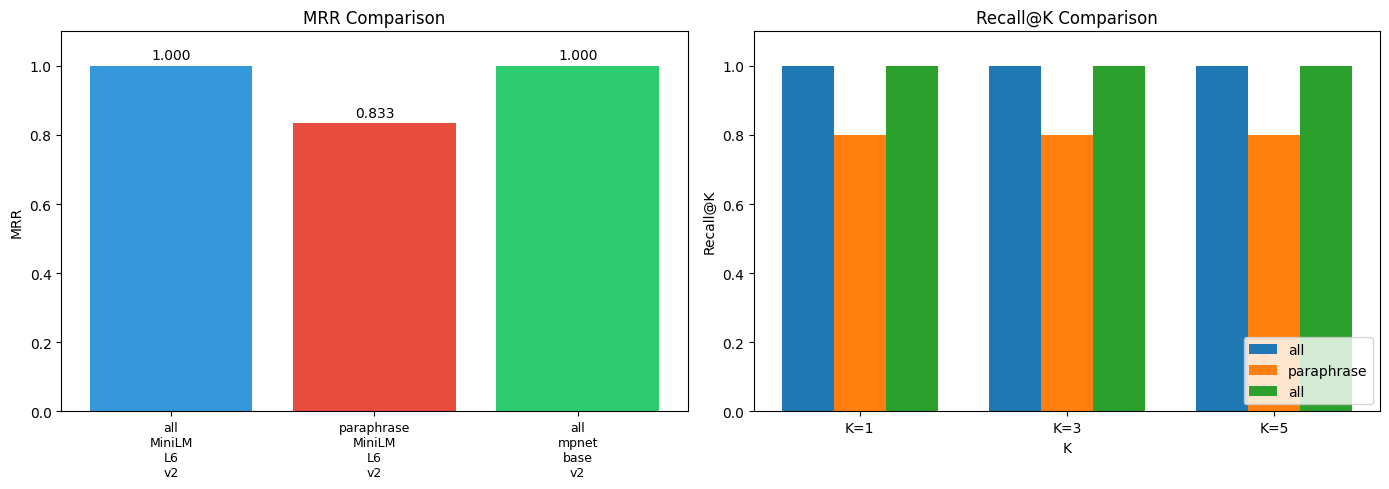

In [11]:
# 視覺化比較結果
if all_results:
    # 轉換為 DataFrame
    df = pd.DataFrame(all_results).T
    
    # 顯示表格
    print("\n📊 模型比較結果:")
    print(df.round(4).to_string())
    
    # 視覺化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # MRR 比較
    ax1 = axes[0]
    models = list(all_results.keys())
    mrr_values = [all_results[m]['MRR'] for m in models]
    bars = ax1.bar(range(len(models)), mrr_values, color=['#3498db', '#e74c3c', '#2ecc71'])
    ax1.set_xticks(range(len(models)))
    ax1.set_xticklabels([m.replace('-', '\n') for m in models], fontsize=9)
    ax1.set_ylabel('MRR')
    ax1.set_title('MRR Comparison')
    ax1.set_ylim(0, 1.1)
    for bar, val in zip(bars, mrr_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{val:.3f}', ha='center', fontsize=10)
    
    # Recall@K 比較
    ax2 = axes[1]
    k_values = [1, 3, 5]
    x = np.arange(len(k_values))
    width = 0.25
    
    for i, model_name in enumerate(models):
        recalls = [all_results[model_name][f'Recall@{k}'] for k in k_values]
        ax2.bar(x + i * width, recalls, width, label=model_name.split('-')[0])
    
    ax2.set_xlabel('K')
    ax2.set_ylabel('Recall@K')
    ax2.set_title('Recall@K Comparison')
    ax2.set_xticks(x + width)
    ax2.set_xticklabels([f'K={k}' for k in k_values])
    ax2.legend(loc='lower right')
    ax2.set_ylim(0, 1.1)
    
    plt.tight_layout()
    plt.show()

---
## 📈 Part 5: MTEB 基準測試介紹

### 什麼是 MTEB？

**MTEB (Massive Text Embedding Benchmark)** 是一個標準化的 embedding 評估框架：

- 涵蓋 8 種任務類型：Retrieval, Reranking, Classification, Clustering, STS, Summarization, BitextMining, PairClassification
- 支援 58+ 資料集
- 統一的評估標準，方便比較

### MTEB Leaderboard
可在 https://huggingface.co/spaces/mteb/leaderboard 查看最新排名

In [13]:
# MTEB 使用範例（小型資料集，快速演示）
try:
    import mteb
    
    print("📥 載入 MTEB...")
    
    # 載入模型
    model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # 選擇一個小型任務進行評估
    # STS (Semantic Textual Similarity) 任務
    tasks = mteb.get_tasks(tasks=["STS12"])  # 使用較小的 STS12 資料集
    
    print(f"\n🔄 正在評估 {len(tasks)} 個任務...")
    print("(這可能需要幾分鐘)")
    
    evaluation = mteb.MTEB(tasks=tasks)
    results = evaluation.run(model, output_folder="mteb_results")
    
    print("\n✅ MTEB 評估完成！")
    print("結果已儲存至 mteb_results/ 目錄")
    
except ImportError:
    print("⚠️ MTEB 未安裝。請執行: pip install mteb")
except Exception as e:
    print(f"⚠️ MTEB 評估時發生錯誤: {e}")
    print("這可能是因為資料集下載問題。您可以稍後再試。")

⚠️ MTEB 未安裝。請執行: pip install mteb


---
## 🏋️ 練習: 建立你自己的評估資料集

設計一個針對特定領域的評估資料集（例如：技術文件、客服問答等）

In [14]:
# TODO: 建立你自己的評估資料集

# 範例：技術文件 FAQ
my_corpus = [
    "How to install Python? Download from python.org and run the installer.",
    "What is a virtual environment? An isolated Python environment for project dependencies.",
    "How to install packages with pip? Use 'pip install package_name' command.",
    # 加入更多文件...
]

my_queries = [
    "Installing Python on Windows",
    "What is venv?",
    "pip usage",
]

my_relevant = [
    {0},  # Query 0 -> 文件 0
    {1},  # Query 1 -> 文件 1
    {2},  # Query 2 -> 文件 2
]

# 評估
model = SentenceTransformer('all-MiniLM-L6-v2')
evaluator = EmbeddingEvaluator(model)
results = evaluator.evaluate_retrieval(
    queries=my_queries,
    corpus=my_corpus,
    relevant_docs=my_relevant,
    k_values=[1, 3]
)
evaluator.print_results(results)

🔄 正在編碼文件庫...


Batches: 100%|██████████| 1/1 [00:00<00:00, 329.59it/s]


🔄 正在編碼查詢...


Batches: 100%|██████████| 1/1 [00:00<00:00, 414.54it/s]

🔄 正在計算相似度...

📊 評估結果
  MRR: 1.0000
  Recall@1: 1.0000
  Precision@1: 1.0000
  Recall@3: 1.0000
  Precision@3: 0.3333


---
## 📝 總結

### 本實驗學到的重點

1. **評估指標**
   - MRR：衡量找到第一個正確答案的速度
   - NDCG：考慮排名和相關性的綜合指標
   - Recall@K：召回率
   - Precision@K：精確率

2. **評估 Pipeline**
   - 需要準備查詢、文件庫和標註資料
   - 可以封裝成可重複使用的類別

3. **MTEB**
   - 標準化的 embedding 評估框架
   - 適合全面評估模型能力

### 下一步
在 Lab 03 中，我們將學習如何準備 finetune 所需的訓練資料！

---
## 📚 參考資源

- [MTEB Leaderboard](https://huggingface.co/spaces/mteb/leaderboard)
- [MTEB Paper](https://arxiv.org/abs/2210.07316)
- [BEIR Benchmark](https://github.com/beir-cellar/beir)
- [Information Retrieval 評估指標詳解](https://en.wikipedia.org/wiki/Evaluation_measures_(information_retrieval))